### Problem Statement
# Walmart is an American multinational retail corporation that operates a chain of supercenters, discount
department stores, and grocery stores in the United States.
Walmart serves more than 100 million customers worldwide.
# The Management Team at Walmart Inc. wants to analyze customer purchase behavior—specifically
purchase amount—in relation to customer gender and various other factors to support better
business decisions.
# They want to understand whether spending habits differ between male and female customers:
Do women spend more on Black Friday than men?


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [5]:
df = pd.read_csv("../../assets/walmart_data.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [7]:
df.shape

(550068, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [11]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [13]:
df.describe(include='object')

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068,550068
unique,3631,2,7,3,5
top,P00265242,M,26-35,B,1
freq,1880,414259,219587,231173,193821


In [15]:
df[df.duplicated()].shape

(0, 10)

Analyzing the Gender column

In [17]:
df['Gender'].value_counts()

Gender
M    414259
F    135809
Name: count, dtype: int64

purchases percentage by Gender

In [18]:
df['Gender'].value_counts(normalize=True)

Gender
M    0.753105
F    0.246895
Name: proportion, dtype: float64

Gender wise unique count

In [19]:
df.groupby('Gender')['User_ID'].nunique()

Gender
F    1666
M    4225
Name: User_ID, dtype: int64

In [20]:
df.groupby('Gender')['Purchase'].describe().T

Gender,F,M
count,135809.000000,414259.00000
mean,8734.565765,9437.52604
std,4767.233289,5092.18621
min,12.000000,12.00000
25%,5433.000000,5863.00000
50%,7914.000000,8098.00000
75%,11400.000000,12454.00000
max,23959.000000,23961.00000


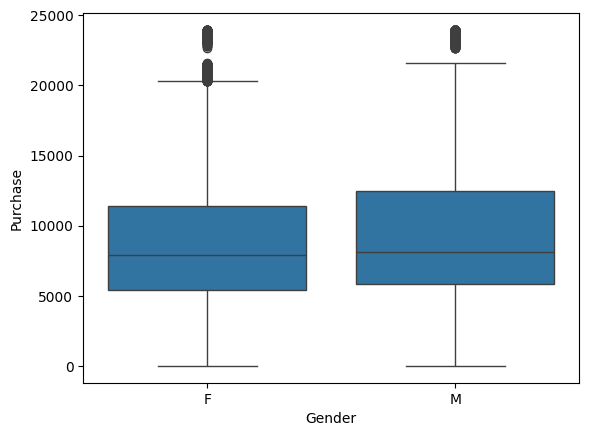

In [21]:
sns.boxplot(x='Gender', y='Purchase', data=df)
plt.show()

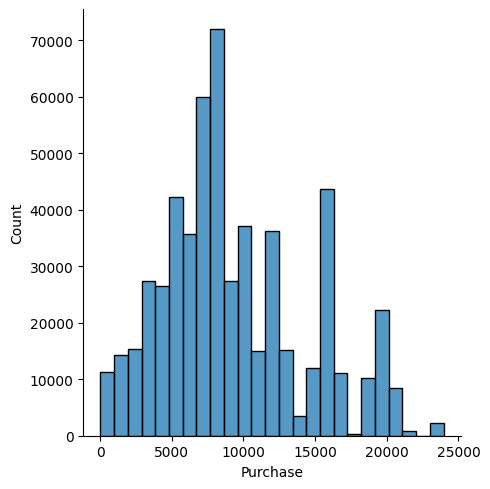

In [27]:
sns.displot(data=df,x='Purchase', bins=25)
plt.show()

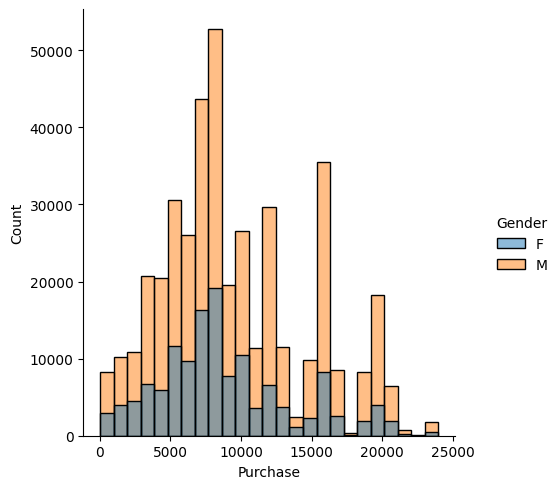

In [24]:
sns.displot(x='Purchase', data=df, hue='Gender', bins=25)

CLT - Central Limit Theorem

In [30]:
male_sample_means = [df[df['Gender']=='M']['Purchase'].sample(3000).mean() for _ in range(1000)]

In [ ]:
female_sample_means = [df[df['Gender']=='F']['Purchase'].sample(3000).mean() for _ in range(1000)]

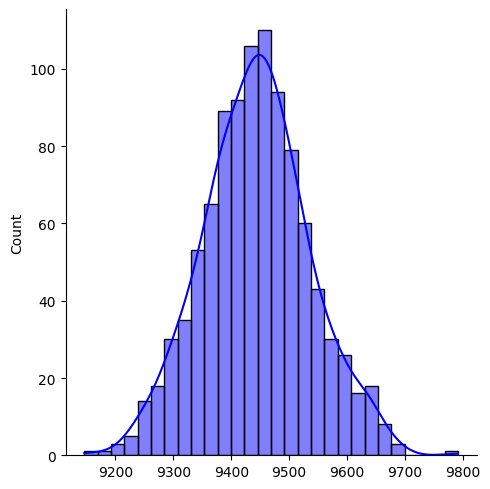

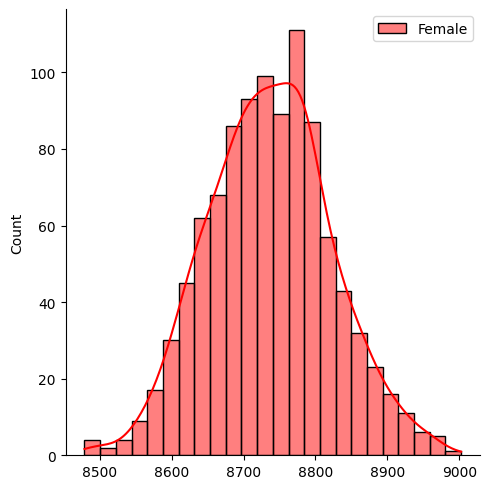

In [29]:
sns.displot(male_sample_means, color='blue', label='Male', kde=True)
sns.displot(female_sample_means, color='red', label='Female', kde=True)
plt.legend()
plt.show()

In [38]:
female_sample_means = [df[df['Gender']=='F']['Purchase'].sample(30000).mean() for _ in range(1000)]

In [31]:
male_sample_means = [df[df['Gender']=='M']['Purchase'].sample(30000).mean() for _ in range(1000)]

In [42]:
np.mean(male_sample_means), np.mean(female_sample_means)

(np.float64(9438.541417466666), np.float64(8734.250249))

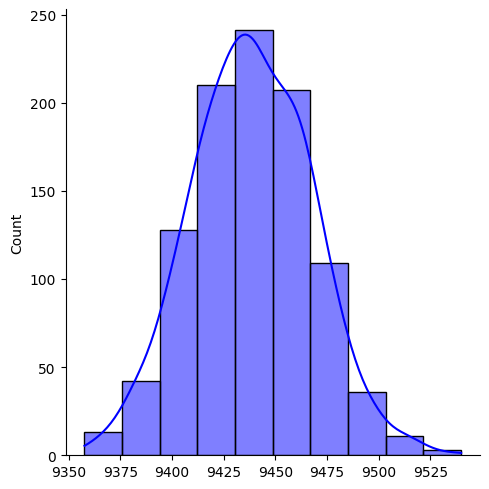

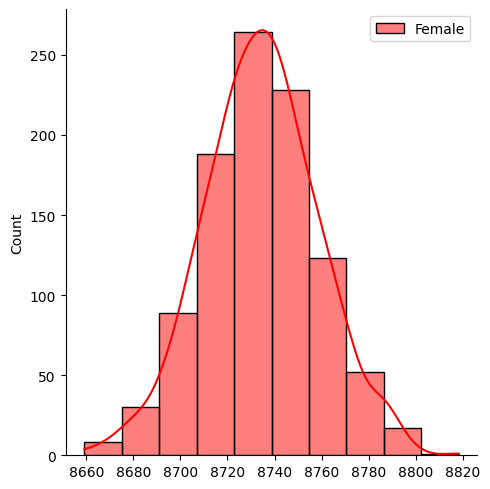

In [43]:
sns.displot(male_sample_means, color='blue', label='Male', kde=True,bins=10)
sns.displot(female_sample_means, color='red', label='Female', kde=True,bins=10)
plt.legend()
plt.show()

Confidence Interval

In [44]:
## 95% Confidence Interval
lower_limit_males = np.mean(male_sample_means) - (1.96*np.std(male_sample_means))
upper_limit_males = np.mean(male_sample_means) + (1.96*np.std(male_sample_means))

(lower_limit_males, upper_limit_males)

(np.float64(9381.869729631526), np.float64(9495.213105301806))

np.float64(9495.213105301806)

In [45]:
lower_limit_females = np.mean(female_sample_means) - (1.96*np.std(female_sample_means))
upper_limit_females = np.mean(female_sample_means) + (1.96*np.std(female_sample_means))
(lower_limit_females, upper_limit_females)

(np.float64(8687.03595334008), np.float64(8781.46454465992))

[]

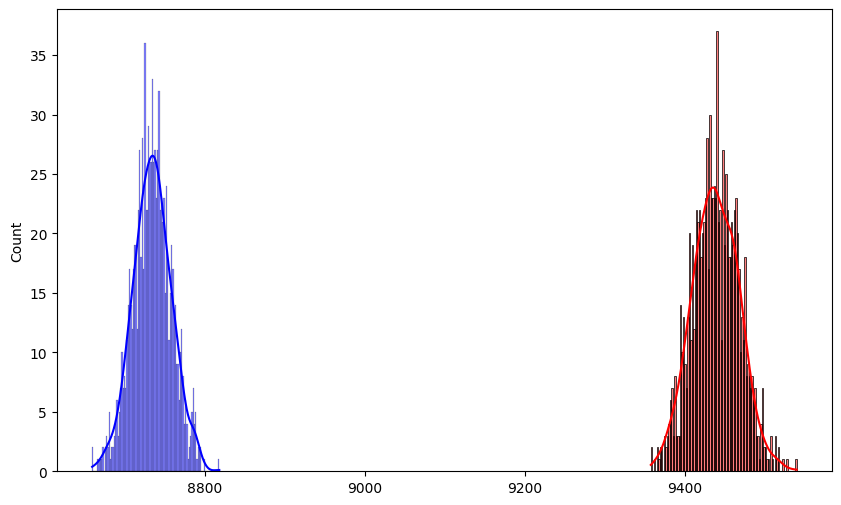

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(male_sample_means,kde=True,color='red',bins=100)
sns.histplot(female_sample_means,kde=True,color='blue',bins=100)
plt.plot()